# Calibration du Modele de Heston — SPY Options

**Calibration par inversion de Fourier** sur donnees reelles d'options SPY.

3 methodes comparees : Levenberg-Marquardt, Evolution Differentielle, Hybride (DE+LM).

**Plan :**
1. Chargement et exploration des donnees
2. Validation synthetique
3. Calibration multi-jours (3 methodes)
4. Analyse du fit + condition de Feller
5. Comparaison Heston vs Black-Scholes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
import time

from heston import (
    HestonParams, HestonPricer, BlackScholes,
    MarketData, HestonCalibrator,
    CalibrationResult, compare_results,
)

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print("Imports OK")

Imports OK


## 1 — Chargement des donnees

| Fichier | Periode | Contexte |
|---|---|---|
| `spy_options_data_19.json` | 2019 | Haussier, vol basse |
| `spy_options_data_20.json` | 2020 | COVID, vol extreme |
| `spy_options_data_21.json` | 2021 | Recovery |
| `spy_options_data_22.json` | 2022 | Bear market |
| `spy_options_data_23.json` | 2023 | Rally IA |
| `spy_options_data_24.json` | 2024 | Normalisation |

In [2]:
# Configuration
DATA_FILE = "data/spy_options_data_24.json"
N_DAYS = 5   # nombre de jours
MIN_STRIKES_PER_MATURITY = 15     

markets = MarketData.from_json(
    DATA_FILE,
    day_indices=list(range(N_DAYS)),
    r=0.05,
    q=0.013,
    min_maturity_days=14,
    max_maturity_days=550,
    moneyness_range=(0.85, 1.15),
    iv_range=(0.03, 0.80),
    min_volume=1,
    min_oi=10,
    min_options_per_maturity=MIN_STRIKES_PER_MATURITY,
)

# On prend le jour le plus riche pour les visualisations
market = max(markets, key=lambda m: len(m.strikes))
print(f"Jour retenu pour visualisation : {market}")

Fichier : spy_options_data_24.json (252 jours, 5 selectionnes)
  2024-01-02 : S0=472.69, 3975 -> 704 opts, 18 mats
  2024-01-03 : S0=468.96, 3894 -> 722 opts, 18 mats
  2024-01-04 : S0=467.41, 3889 -> 746 opts, 17 mats
  2024-01-05 : S0=467.98, 3809 -> 740 opts, 18 mats
  2024-01-08 : S0=474.57, 3637 -> 690 opts, 17 mats
Total : 5 jours charges, 3602 options

Jour retenu pour visualisation : MarketData(2024-01-04, S0=467.41, 746 opts, 17 mats)


## 2 — Exploration des donnees filtrees

In [3]:
# Statistiques par maturite
df = market.df.copy()
print(f"S0 = {market.S0:.2f}")
print(f"Total : {len(df)} options, {df['maturity_days'].nunique()} maturites\n")

stats = df.groupby('maturity_days').agg(
    n_options=('strike', 'size'),
    strike_min=('strike', 'min'),
    strike_max=('strike', 'max'),
    iv_mean=('implied_volatility', 'mean'),
    iv_std=('implied_volatility', 'std'),
).round(4)
print(stats.to_string())

S0 = 467.41
Total : 746 options, 17 maturites

               n_options  strike_min  strike_max  iv_mean  iv_std
maturity_days                                                    
15                    61       400.0       488.0   0.1716  0.0774
22                    50       425.0       490.0   0.1403  0.0414
27                    56       400.0       497.0   0.1410  0.0522
29                    43       430.0       495.0   0.1288  0.0262
36                    31       440.0       500.0   0.1208  0.0177
43                    75       400.0       505.0   0.1486  0.0444
56                    49       426.0       515.0   0.1253  0.0254
71                    82       400.0       525.0   0.1462  0.0399
84                    41       440.0       529.0   0.1155  0.0170
106                   22       400.0       535.0   0.1293  0.0309
117                   29       400.0       535.0   0.1385  0.0307
148                   39       405.0       535.0   0.1488  0.0276
169                   41     

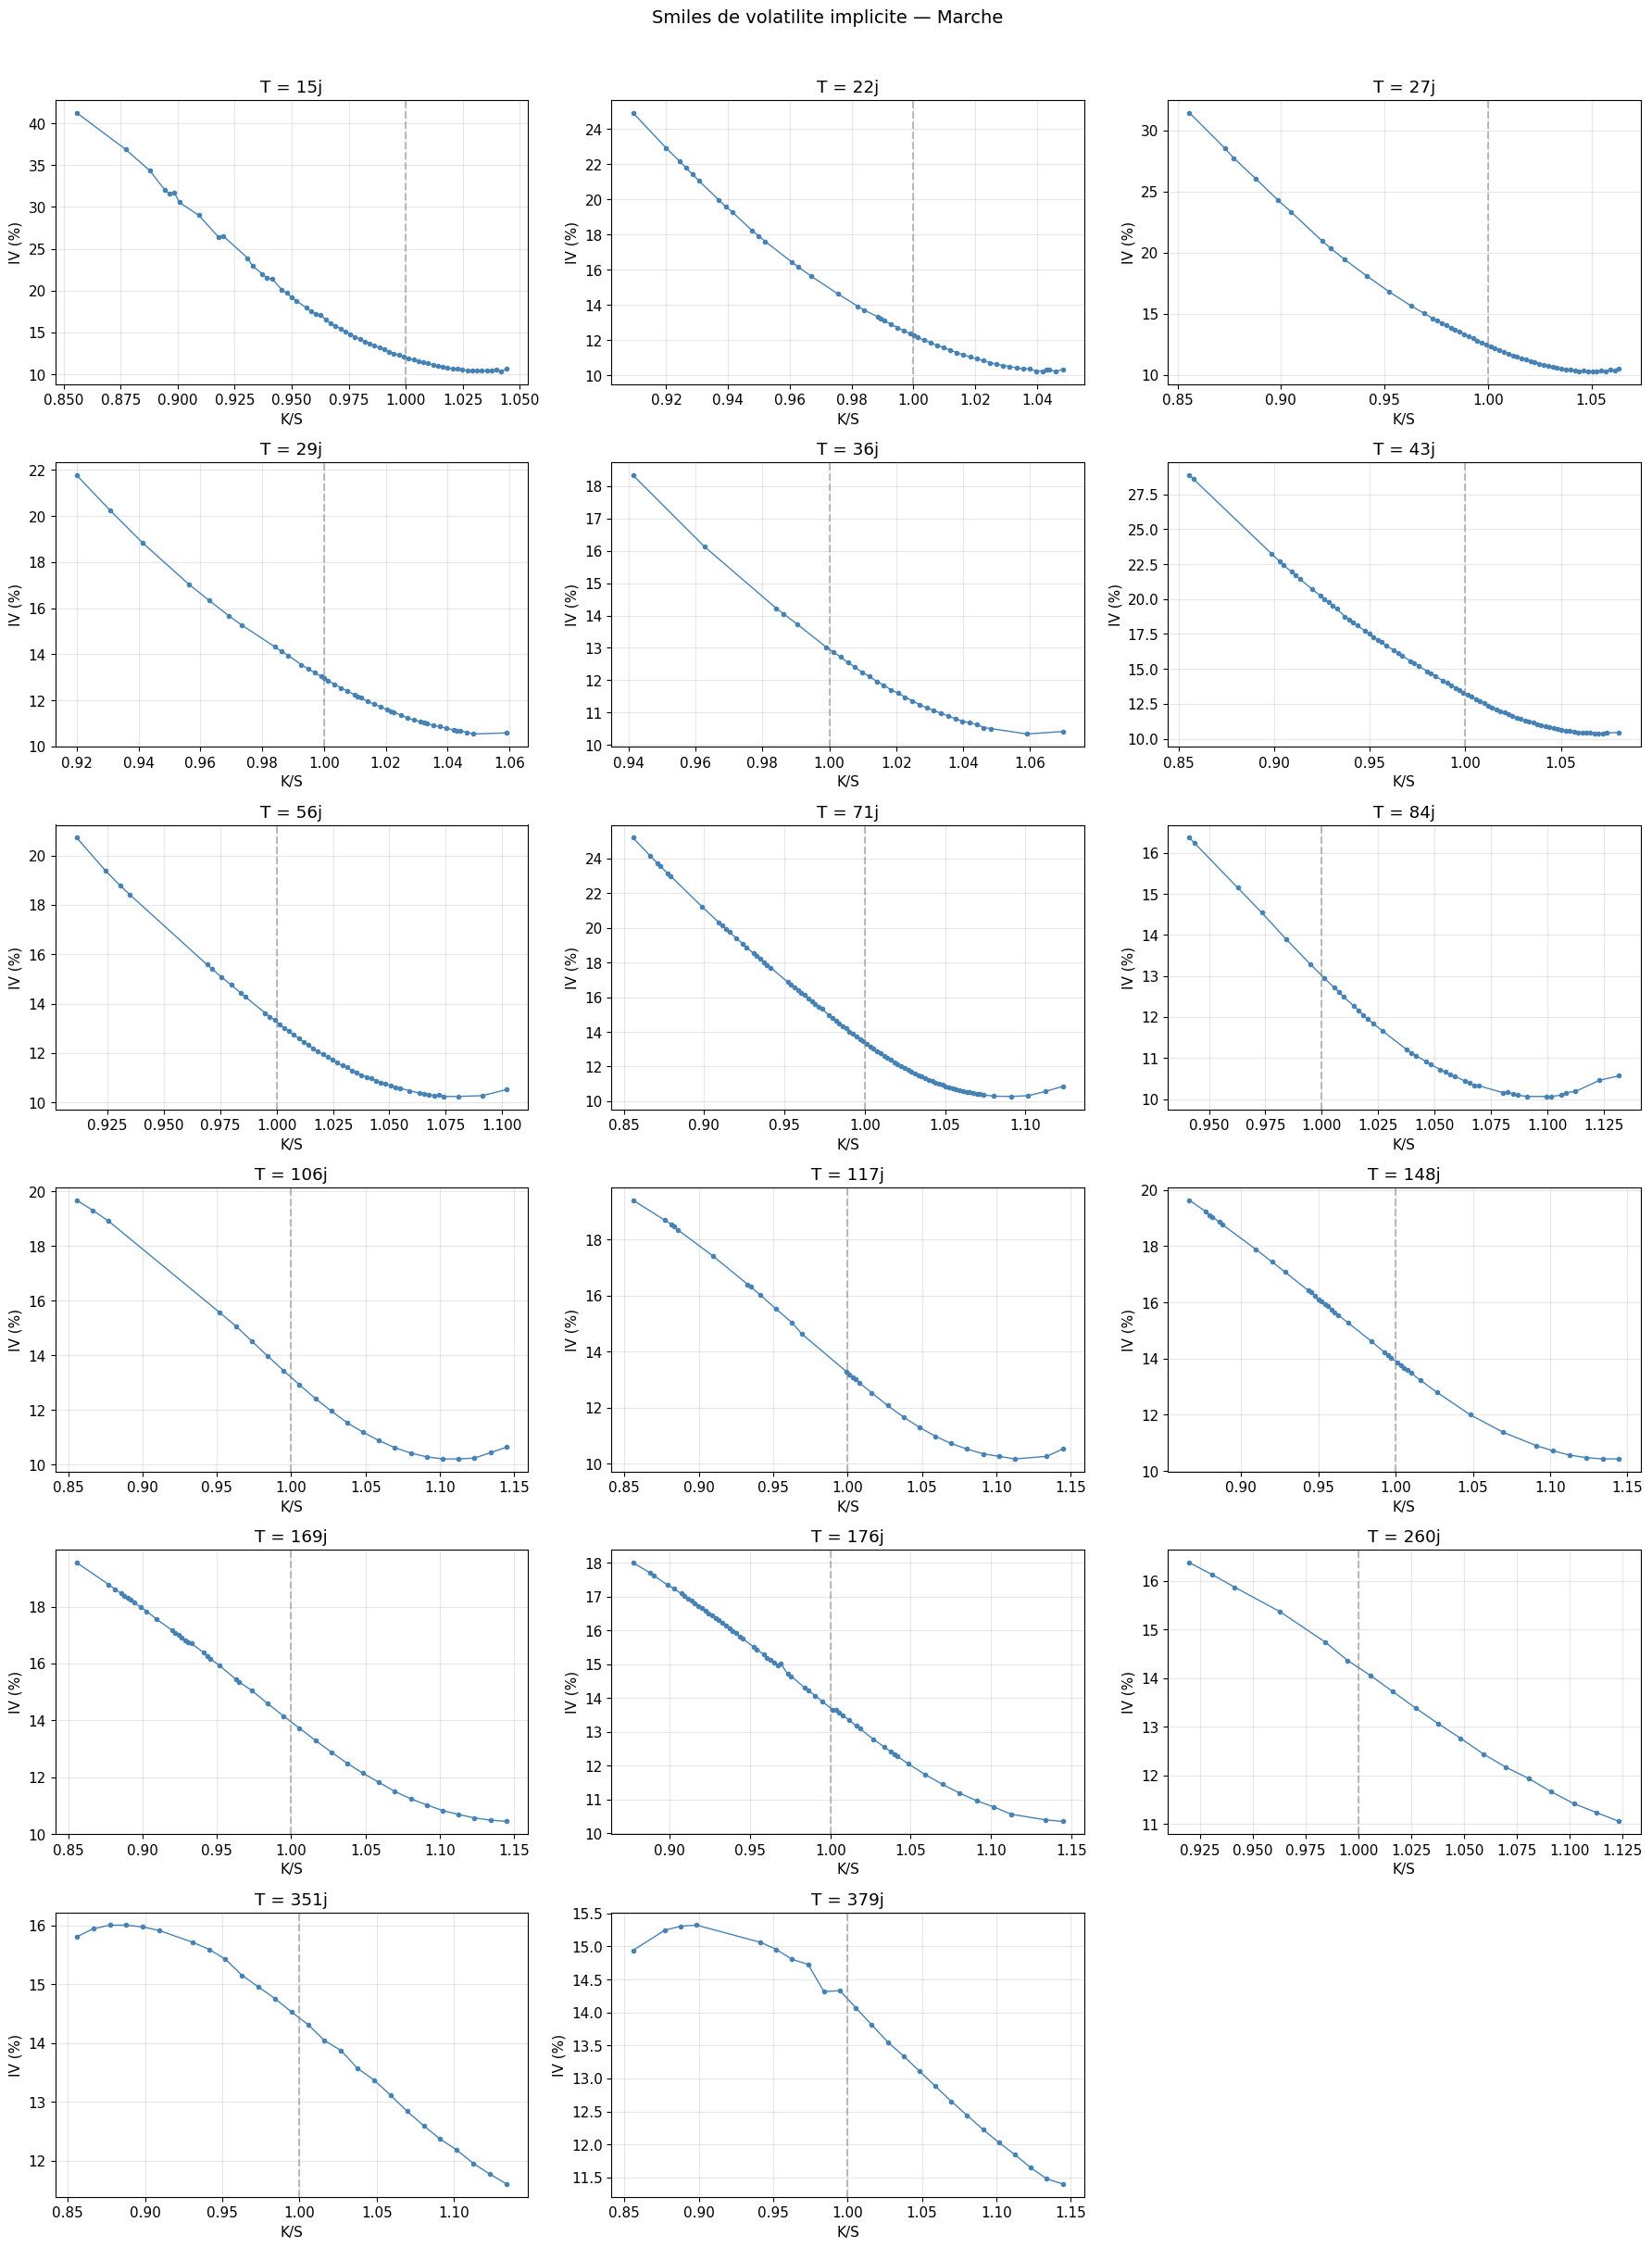

In [4]:
# Smiles de volatilite par maturite
mats = sorted(df['maturity_days'].unique())
n_cols = 3
n_rows = (len(mats) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)

for idx, Td in enumerate(mats):
    ax = axes[idx // n_cols, idx % n_cols]
    sub = df[df['maturity_days'] == Td].sort_values('moneyness')
    ax.plot(sub['moneyness'], sub['implied_volatility'] * 100, 'o-', color='steelblue', ms=3, lw=1)
    ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
    ax.set_title(f'T = {Td}j')
    ax.set_xlabel('K/S')
    ax.set_ylabel('IV (%)')

# Masquer les axes vides
for idx in range(len(mats), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle('Smiles de volatilite implicite — Marche', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3 — Validation synthetique

On verifie que les 3 methodes retrouvent des parametres connus avant de passer aux donnees reelles.

In [5]:
# Donnees synthetiques avec parametres connus
true_params = HestonParams(v0=0.04, kappa=1.5, theta=0.05, sigma=0.4, rho=-0.7)

np.random.seed(42)
synth_market = MarketData.generate_synthetic(
    true_params=true_params,
    n_strikes=10,
    n_maturities=5,
    noise=0.003,
)

# Calibration par les 3 methodes
calibrator = HestonCalibrator(synth_market)
synth_results = [
    calibrator.calibrate(method="lm"),
    calibrator.calibrate(method="de", de_maxiter=40, de_popsize=15),
    calibrator.calibrate(method="hybrid", de_maxiter=20, de_popsize=10),
]

compare_results(synth_results, true_params=true_params)

[Synthetique] S0=100.0, 50 points, params=HestonParams(
  v0    = 0.040000  (vol0  = 0.2000)
  kappa = 1.500000
  theta = 0.050000  (volLT = 0.2236)
  sigma = 0.400000
  rho   = -0.700000
  Feller: NON  (2kT=0.1500 vs s2=0.1600)
)

>> Levenberg-Marquardt (1 jour(s), 50 options)...

>> Evolution Differentielle (1 jour(s), 50 options)...

>> Hybride (DE + LM) (1 jour(s), 50 options)...
  Phase DE terminee, raffinement LM...
Methode                         Temps   Evals   RMSE IV      v0       k      th     sig     rho
-----------------------------------------------------------------------------------------------
Levenberg-Marquardt             0.10s      54    0.0027  0.0398  1.3532  0.0511  0.4107 -0.6928
Evolution Differentielle        4.59s    3207    0.0027  0.0397  1.2652  0.0520  0.4076 -0.6923
Hybride (DE + LM)               1.78s    1262    0.0027  0.0398  1.3532  0.0511  0.4107 -0.6928
----------------------------------------------------------------------------------------------

## 4 — Calibration multi-jours sur donnees reelles

Les 3 methodes sont testees sur les memes jours. Chaque jour garde son propre S0/pricer, les 5 parametres Heston sont partages.

In [6]:
# Calibration multi-jours : 3 methodes comparees
calibrator = HestonCalibrator(markets)

results = [
    calibrator.calibrate(method="lm"),
    calibrator.calibrate(method="de", de_maxiter=40, de_popsize=15),
    calibrator.calibrate(method="hybrid", de_maxiter=25, de_popsize=12),
]

compare_results(results)


>> Levenberg-Marquardt (5 jour(s), 3602 options)...

>> Evolution Differentielle (5 jour(s), 3602 options)...

>> Hybride (DE + LM) (5 jour(s), 3602 options)...
  Phase DE terminee, raffinement LM...
Methode                         Temps   Evals   RMSE IV      v0       k      th     sig     rho
-----------------------------------------------------------------------------------------------
Levenberg-Marquardt             8.20s      97    0.0272  0.0180 10.4494  0.0207  1.0039 -0.6634
Evolution Differentielle      228.87s    3117    0.0274  0.0180 10.3058  0.0207  0.9954 -0.6640
Hybride (DE + LM)             134.52s    1824    0.0272  0.0180 10.4494  0.0207  1.0039 -0.6634

  Meilleure methode : Hybride (DE + LM) (RMSE IV = 0.0272)


In [7]:
# Parametres detailles de chaque methode
for r in results:
    print(r)

== Levenberg-Marquardt ==
  Temps      : 8.20 s
  Evals      : 97
  Jours      : 5
  Options    : 3602
  RMSE prix  : 0.411372
  RMSE IV    : 0.0272  (2.72%)
  HestonParams(
  v0    = 0.018029  (vol0  = 0.1343)
  kappa = 10.449379
  theta = 0.020673  (volLT = 0.1438)
  sigma = 1.003944
  rho   = -0.663356
  Feller: NON  (2kT=0.4320 vs s2=1.0079)
)

== Evolution Differentielle ==
  Temps      : 228.87 s
  Evals      : 3117
  Jours      : 5
  Options    : 3602
  RMSE prix  : 0.411107
  RMSE IV    : 0.0274  (2.74%)
  HestonParams(
  v0    = 0.018012  (vol0  = 0.1342)
  kappa = 10.305790
  theta = 0.020694  (volLT = 0.1439)
  sigma = 0.995371
  rho   = -0.664039
  Feller: NON  (2kT=0.4265 vs s2=0.9908)
)

== Hybride (DE + LM) ==
  Temps      : 134.52 s
  Evals      : 1824
  Jours      : 5
  Options    : 3602
  RMSE prix  : 0.411372
  RMSE IV    : 0.0272  (2.72%)
  HestonParams(
  v0    = 0.018029  (vol0  = 0.1343)
  kappa = 10.449385
  theta = 0.020673  (volLT = 0.1438)
  sigma = 1.003947


## 5 — Condition de Feller

La condition de Feller $2\kappa\theta > \sigma^2$ garantit que la variance reste strictement positive.
Si elle n'est pas satisfaite, le processus de variance peut toucher zero, ce qui est problematique numeriquement.

### Smiles des 3 methodes superposes

On compare visuellement les smiles produits par chaque methode de calibration sur le jour de visualisation.

Calcul IV pour Levenberg-Marquardt...
Calcul IV pour Evolution Differentielle...
Calcul IV pour Hybride (DE + LM)...


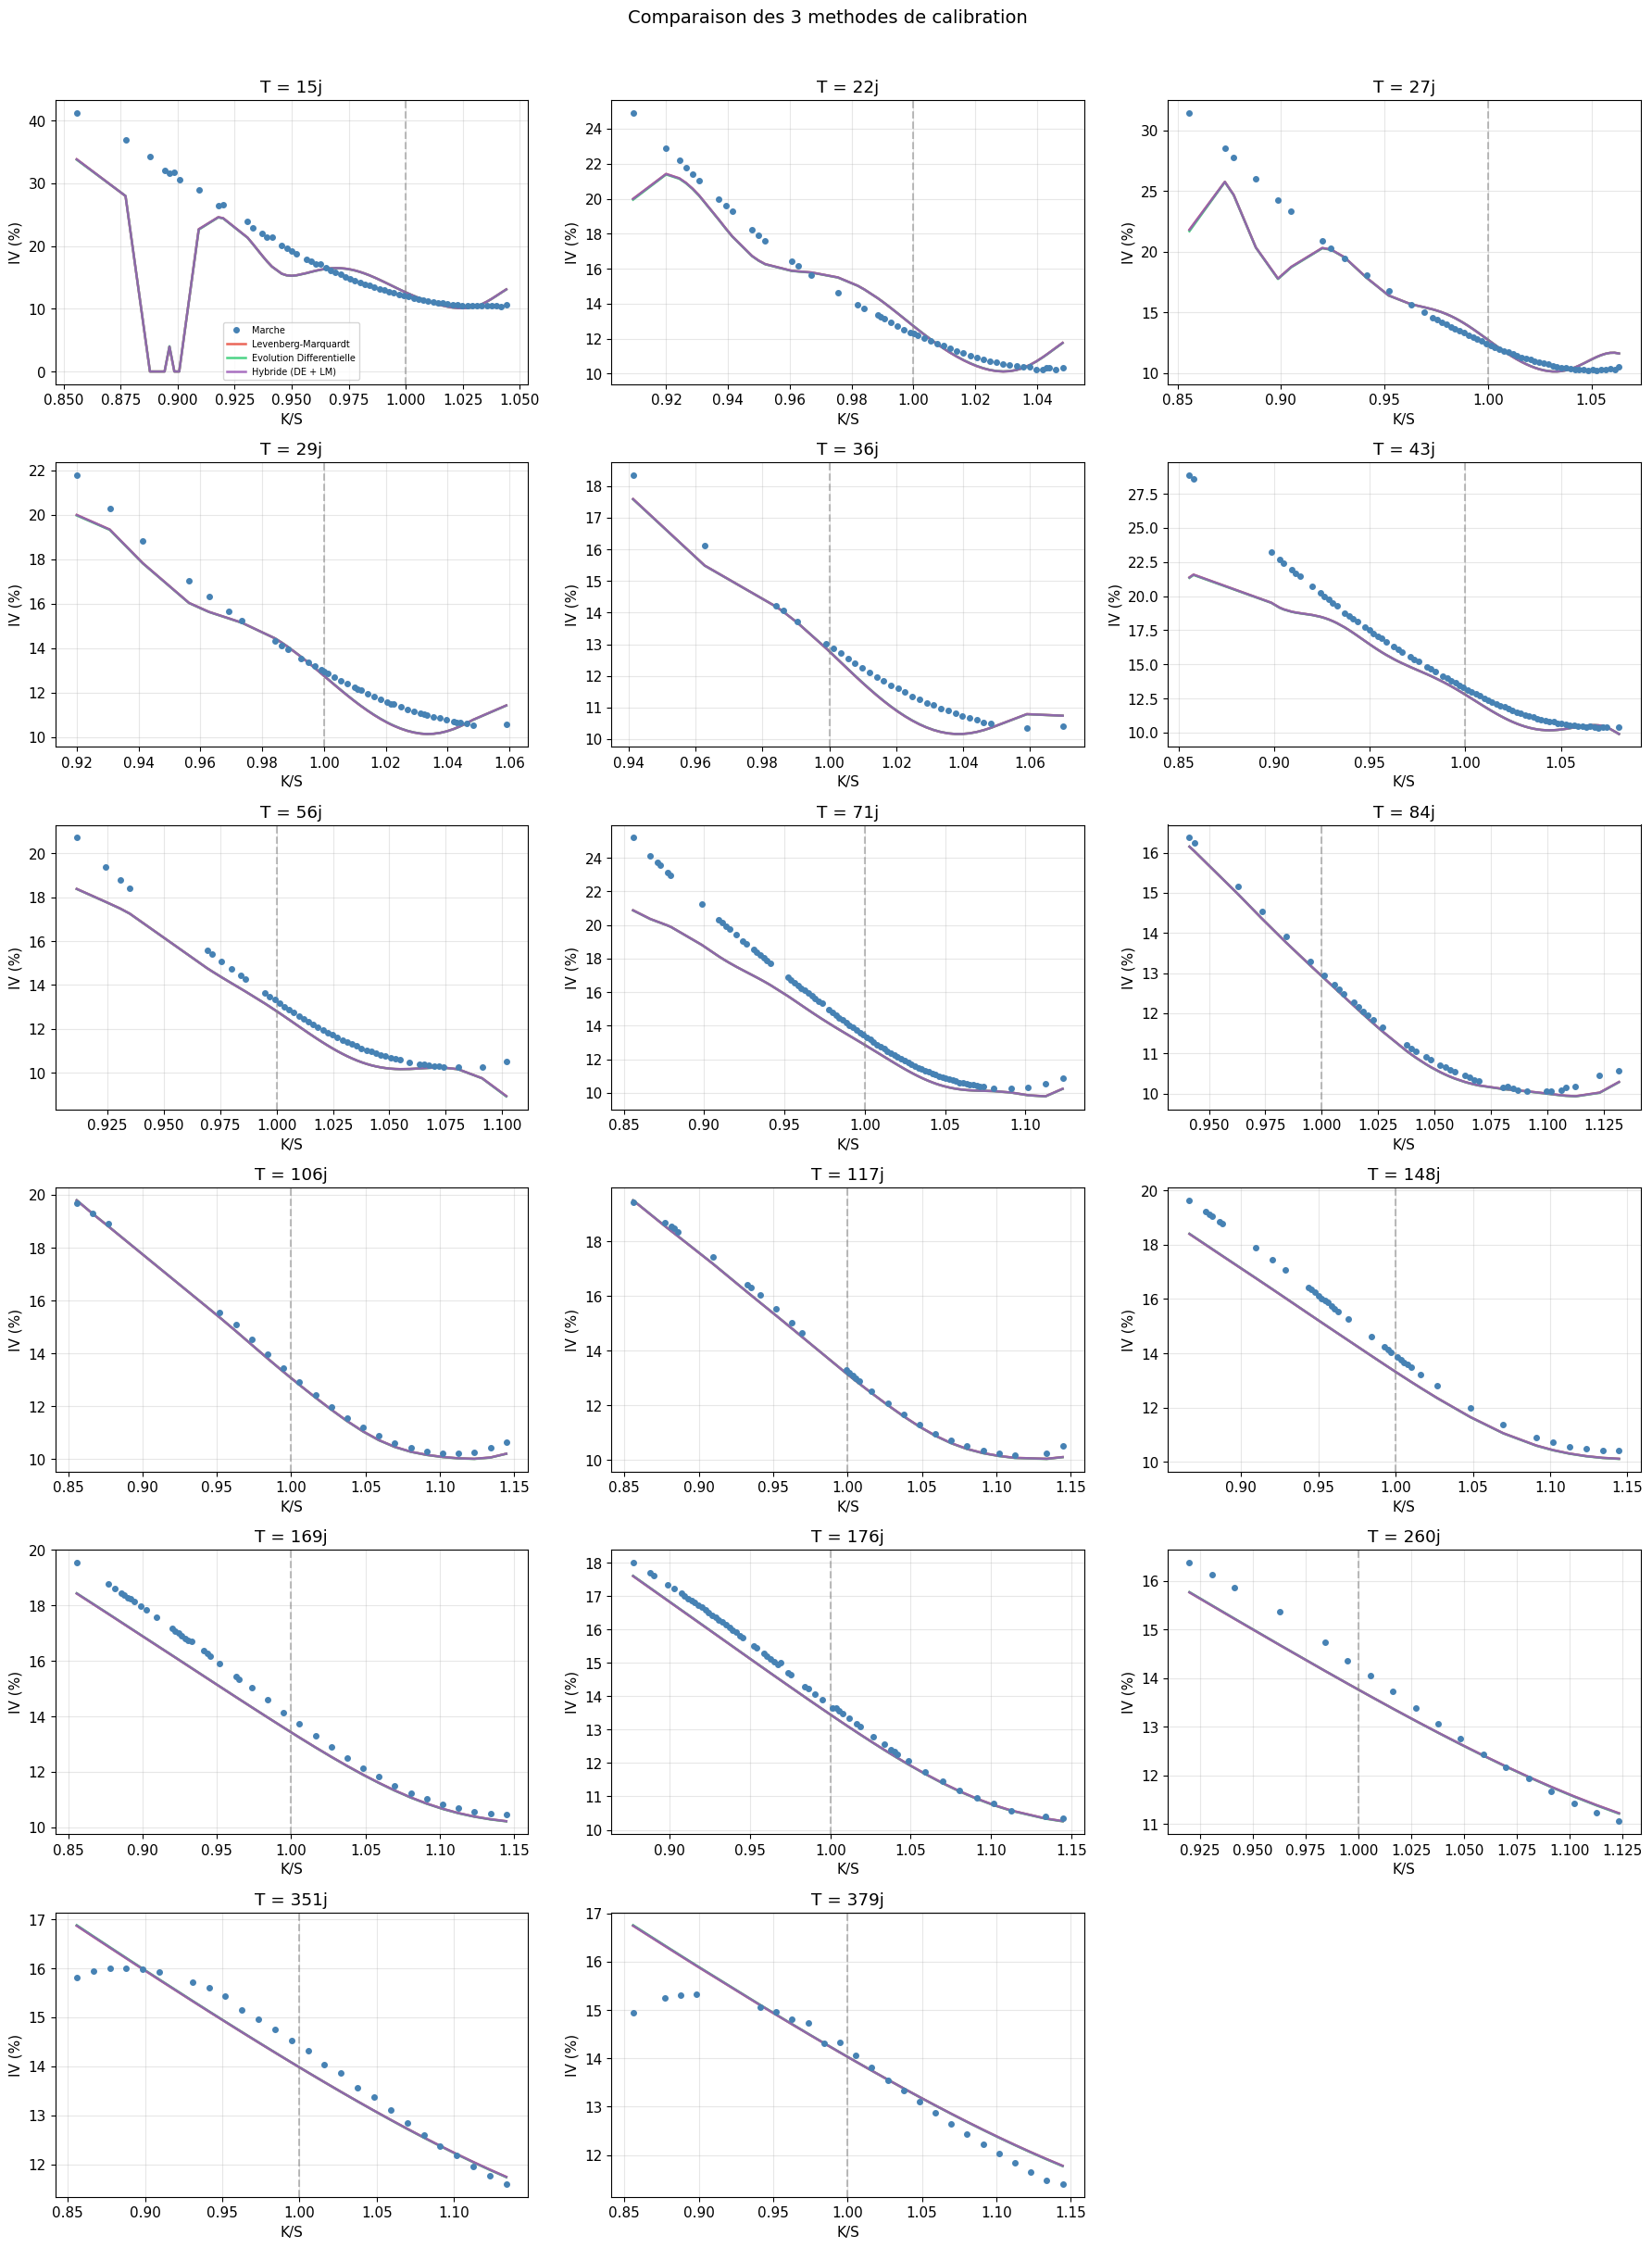


RMSE IV par methode :
  Levenberg-Marquardt          : 2.721%
  Evolution Differentielle     : 2.742%
  Hybride (DE + LM)            : 2.721%


In [8]:
# Calculer les IV Heston pour chaque methode sur le jour de visualisation
df = market.df.copy()
mats = sorted(df['maturity_days'].unique())
n_cols = 3
n_rows = (len(mats) + n_cols - 1) // n_cols

pricer = HestonPricer(market.S0, market.r, market.q)
colors = ['#e74c3c', '#2ecc71', '#9b59b6']  # rouge, vert, violet
method_ivs = {}

for r in results:
    print(f"Calcul IV pour {r.method}...")
    ivs = np.array([
        pricer.implied_vol(K, T, r.params)
        for K, T in zip(market.strikes, market.maturities)
    ])
    method_ivs[r.method] = ivs

# Smiles superposes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)

for idx, Td in enumerate(mats):
    ax = axes[idx // n_cols, idx % n_cols]
    sub = df[df['maturity_days'] == Td].sort_values('moneyness')
    mask = df['maturity_days'] == Td
    idx_mask = df.index[mask]

    # Marche
    ax.plot(sub['moneyness'], sub['implied_volatility'] * 100,
            'o', color='steelblue', ms=4, label='Marche', zorder=5)

    # Chaque methode
    for (method_name, ivs), color in zip(method_ivs.items(), colors):
        sub_ivs = ivs[mask.values]
        ax.plot(sub['moneyness'].values, sub_ivs * 100,
                '-', color=color, lw=1.8, label=method_name, alpha=0.85)

    ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
    ax.set_title(f'T = {Td}j')
    ax.set_xlabel('K/S')
    ax.set_ylabel('IV (%)')
    if idx == 0:
        ax.legend(fontsize=7, loc='best')

for idx in range(len(mats), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle('Comparaison des 3 methodes de calibration', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# RMSE par methode
print("\nRMSE IV par methode :")
for r in results:
    print(f"  {r.method:<28} : {r.rmse_iv*100:.3f}%")

Methode                           2kT       s2    Ratio   Feller
----------------------------------------------------------------
Levenberg-Marquardt            0.4320   1.0079     0.43   VIOLEE
Evolution Differentielle       0.4265   0.9908     0.43   VIOLEE
Hybride (DE + LM)              0.4320   1.0079     0.43   VIOLEE

Ratio > 1 => Feller satisfaite (variance reste > 0)
Ratio < 1 => Feller violee (variance peut toucher 0)


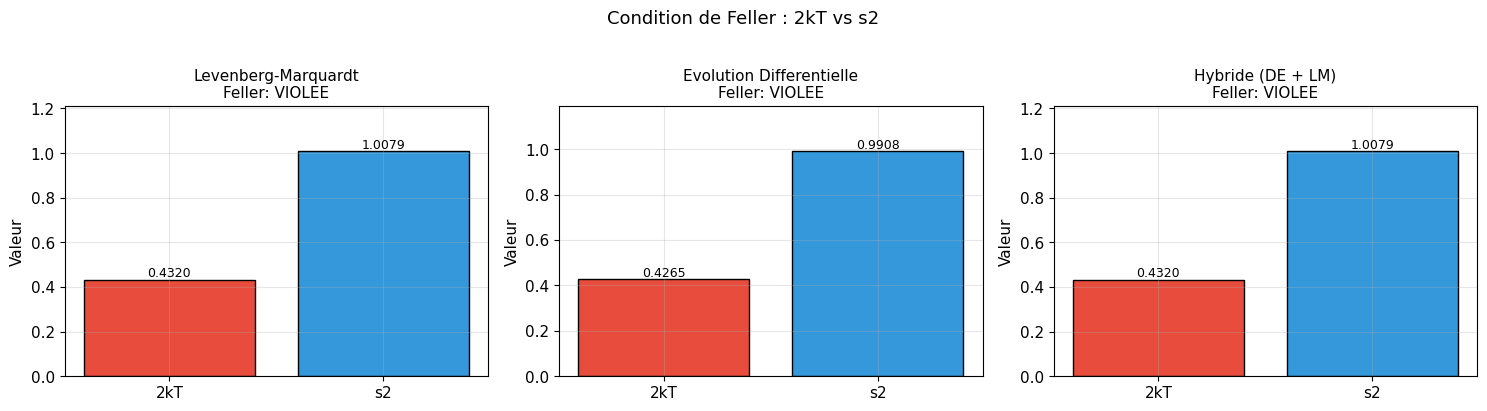

In [9]:
# Verification de la condition de Feller pour chaque methode
print(f"{'Methode':<28} {'2kT':>8} {'s2':>8} {'Ratio':>8} {'Feller':>8}")
print("-" * 64)

for r in results:
    p = r.params
    two_k_theta = 2 * p.kappa * p.theta
    sigma2 = p.sigma ** 2
    ratio = two_k_theta / sigma2
    status = "OK" if p.feller_satisfied else "VIOLEE"
    print(f"{r.method:<28} {two_k_theta:>8.4f} {sigma2:>8.4f} {ratio:>8.2f} {status:>8}")

print("\nRatio > 1 => Feller satisfaite (variance reste > 0)")
print("Ratio < 1 => Feller violee (variance peut toucher 0)")

# Visualisation
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    p = r.params
    two_k_theta = 2 * p.kappa * p.theta
    sigma2 = p.sigma ** 2

    bars = ax.bar(
        ['2kT', 's2'],
        [two_k_theta, sigma2],
        color=['#2ecc71' if p.feller_satisfied else '#e74c3c', '#3498db'],
        edgecolor='black',
    )
    ax.set_title(f'{r.method}\nFeller: {"OK" if p.feller_satisfied else "VIOLEE"}',
                 fontsize=11)
    ax.set_ylabel('Valeur')

    # Ligne de reference
    max_val = max(two_k_theta, sigma2) * 1.2
    ax.set_ylim(0, max_val)
    ax.bar_label(bars, fmt='%.4f', fontsize=9)

plt.suptitle('Condition de Feller : 2kT vs s2', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6 — Analyse du fit

On prend le meilleur resultat (RMSE IV min) et on compare les smiles Heston vs marche.

In [10]:
# Meilleur resultat
best = min(results, key=lambda r: r.rmse_iv)
params_cal = best.params
print(f"Meilleure methode : {best.method}")
print(params_cal)

# Calculer les IV Heston sur le jour de visualisation
pricer = HestonPricer(market.S0, market.r, market.q)

t0 = time.time()
iv_heston = np.array([
    pricer.implied_vol(K, T, params_cal)
    for K, T in zip(market.strikes, market.maturities)
])
print(f"\nCalcul des IV Heston : {time.time() - t0:.1f}s pour {len(market.strikes)} options")

df['iv_heston'] = iv_heston
df['err_heston'] = (df['iv_heston'] - df['implied_volatility']) * 100

Meilleure methode : Hybride (DE + LM)
HestonParams(
  v0    = 0.018029  (vol0  = 0.1343)
  kappa = 10.449385
  theta = 0.020673  (volLT = 0.1438)
  sigma = 1.003947
  rho   = -0.663355
  Feller: NON  (2kT=0.4320 vs s2=1.0079)
)

Calcul des IV Heston : 0.4s pour 746 options


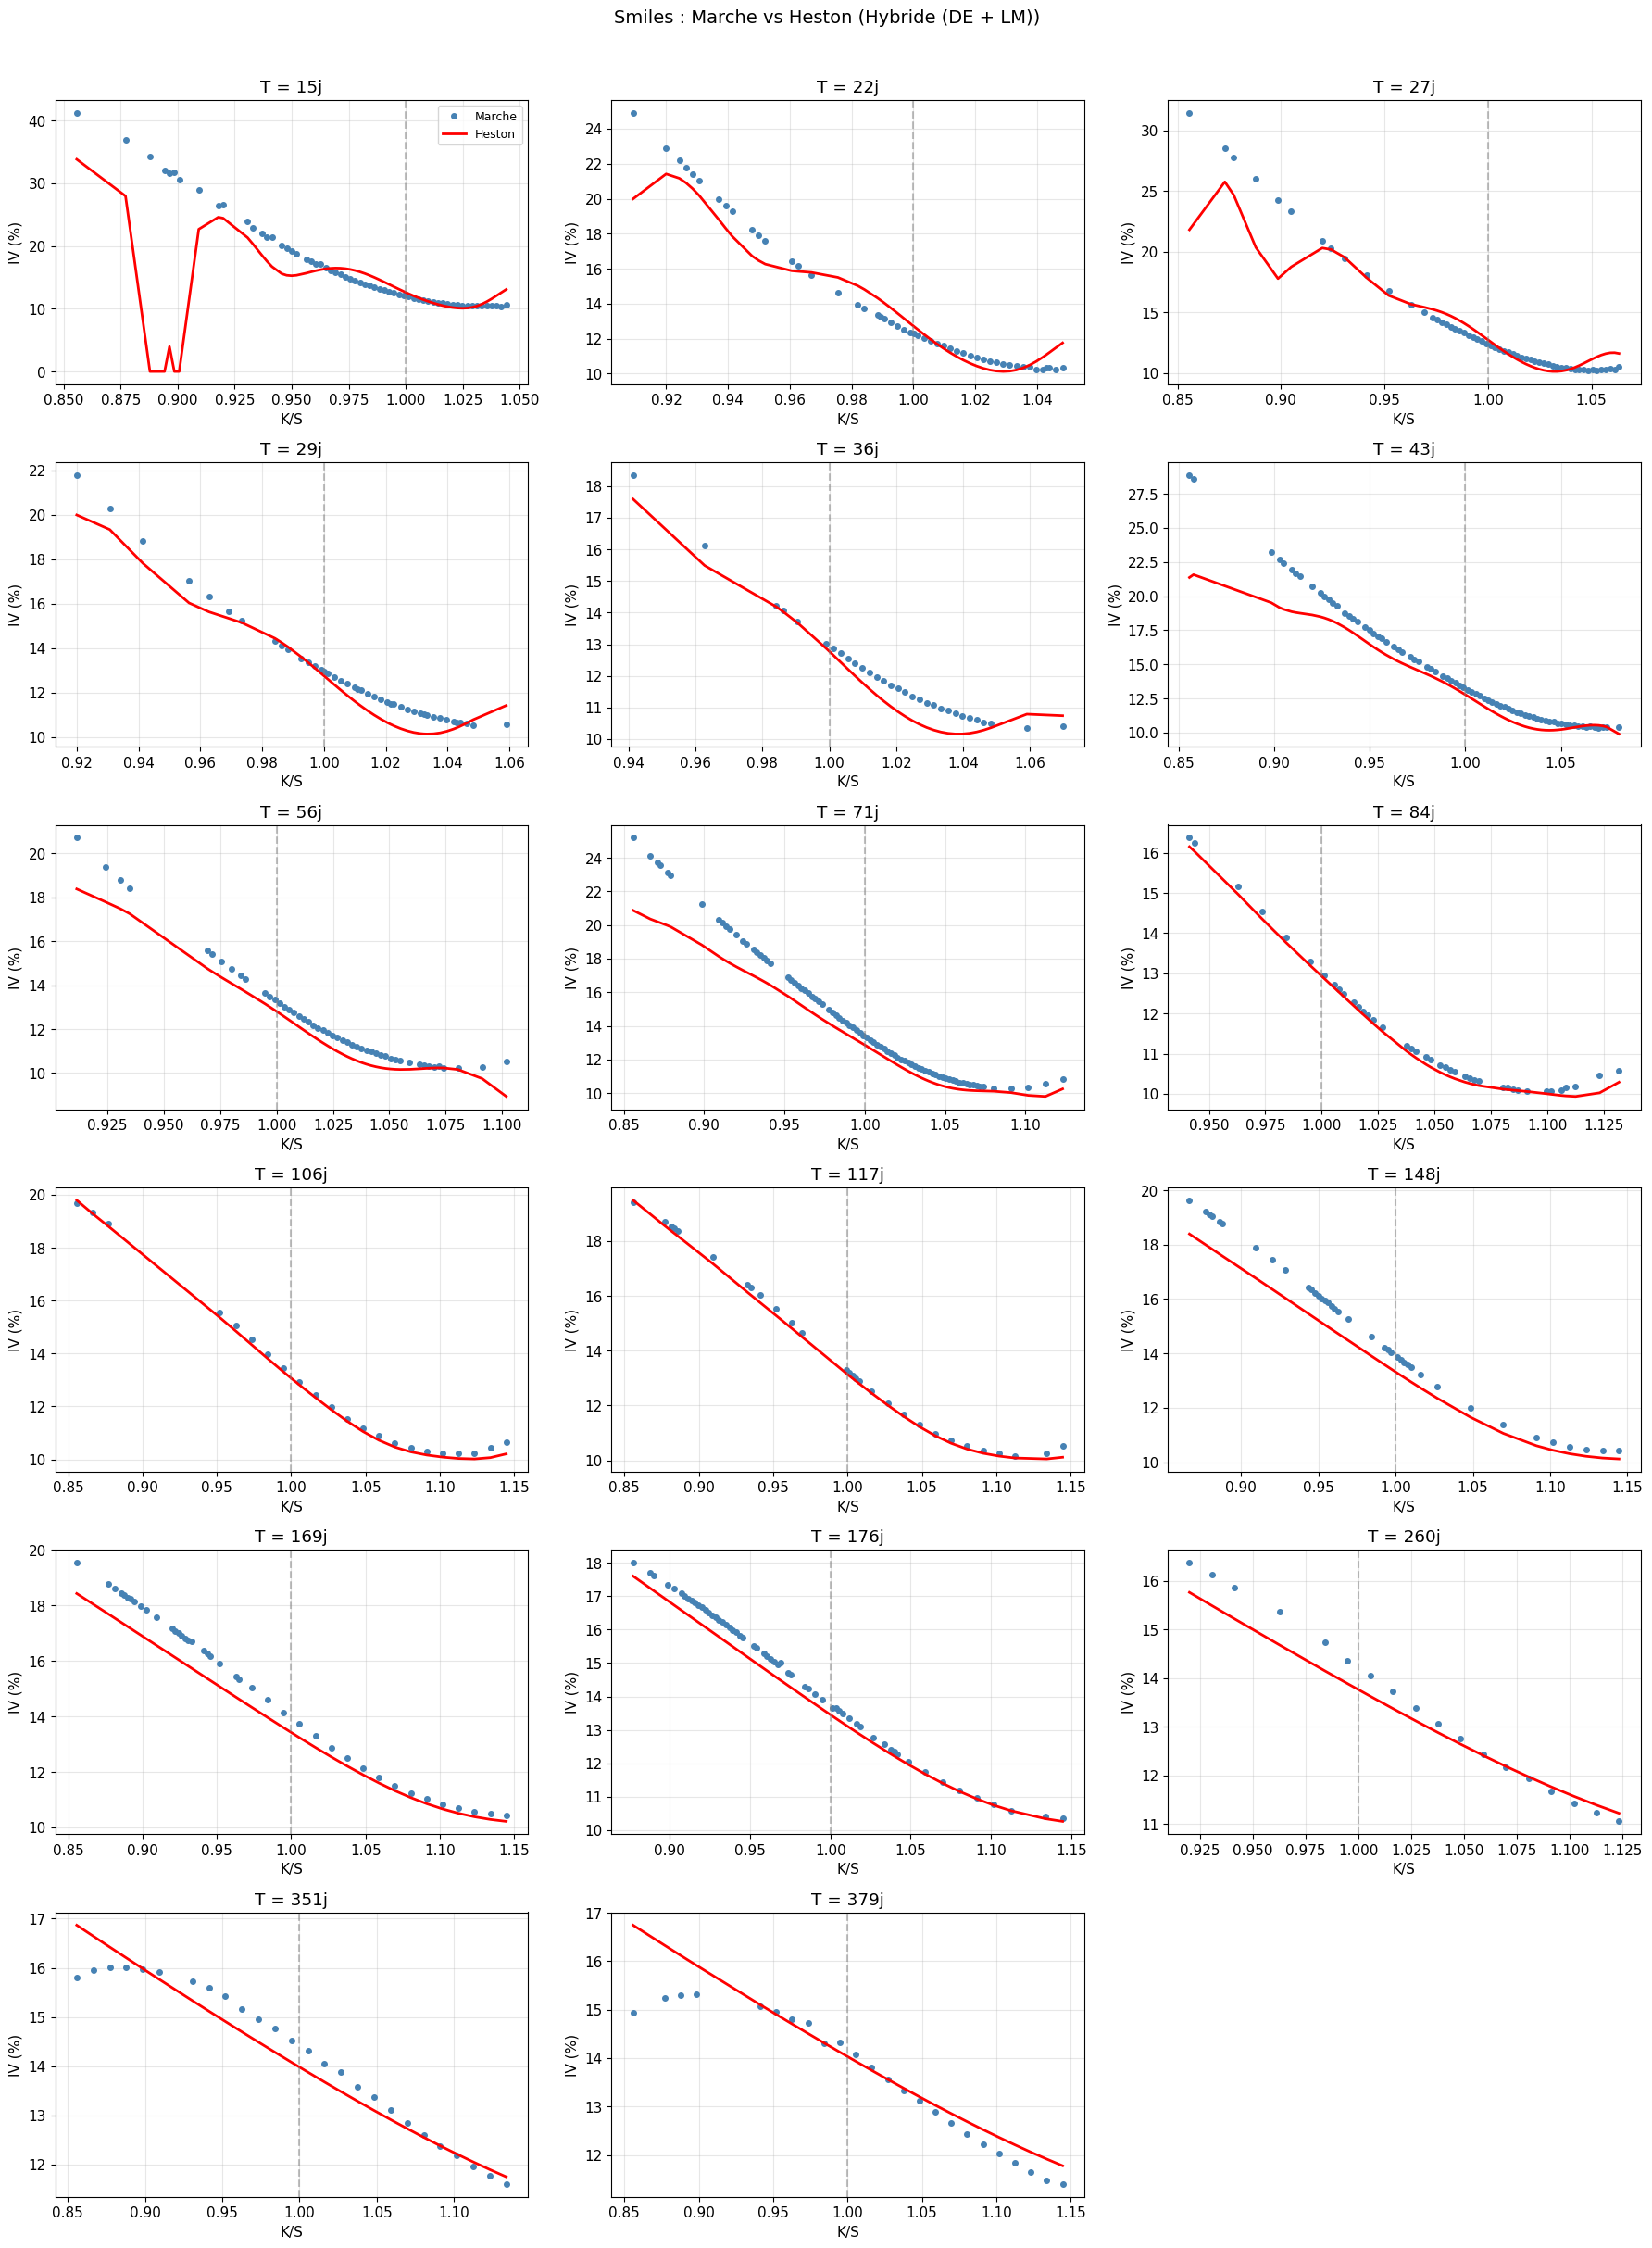

In [11]:
# Smiles : Marche vs Heston calibre
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)

for idx, Td in enumerate(mats):
    ax = axes[idx // n_cols, idx % n_cols]
    sub = df[df['maturity_days'] == Td].sort_values('moneyness')
    ax.plot(sub['moneyness'], sub['implied_volatility'] * 100, 'o', color='steelblue', ms=4, label='Marche')
    ax.plot(sub['moneyness'], sub['iv_heston'] * 100, '-', color='red', lw=2, label='Heston')
    ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
    ax.set_title(f'T = {Td}j')
    ax.set_xlabel('K/S')
    ax.set_ylabel('IV (%)')
    if idx == 0:
        ax.legend(fontsize=9)

for idx in range(len(mats), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle(f'Smiles : Marche vs Heston ({best.method})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

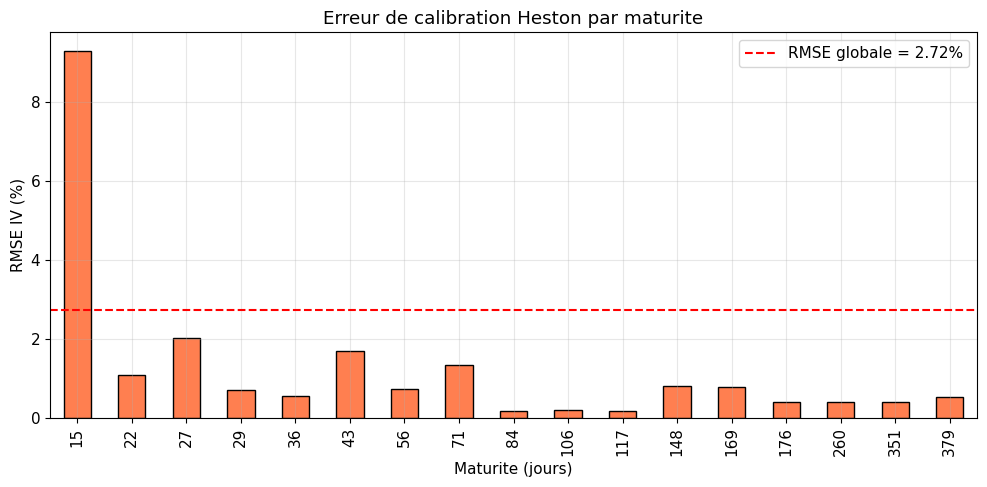

In [12]:
# RMSE par maturite
rmse_by_mat = df.groupby('maturity_days').apply(
    lambda g: np.sqrt(np.mean((g['iv_heston'] - g['implied_volatility'])**2)) * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
rmse_by_mat.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Maturite (jours)')
ax.set_ylabel('RMSE IV (%)')
ax.set_title('Erreur de calibration Heston par maturite')
ax.axhline(best.rmse_iv * 100, color='red', ls='--', label=f'RMSE globale = {best.rmse_iv*100:.2f}%')
ax.legend()
plt.tight_layout()
plt.show()

## 7 — Comparaison Black-Scholes vs Heston

Black-Scholes utilise une volatilite constante (IV ATM moyenne) : il ne peut pas capturer le smile.
Heston, avec sa volatilite stochastique, reproduit le skew et la structure par terme.

In [13]:
# BS flat : sigma = IV ATM moyenne
atm_mask = (df['moneyness'] > 0.98) & (df['moneyness'] < 1.02)
sigma_bs = df.loc[atm_mask, 'implied_volatility'].mean()
print(f"sigma_BS (ATM) = {sigma_bs*100:.2f}%")

# Erreurs (en %)
err_bs = (sigma_bs - df['implied_volatility'].values) * 100
err_heston = (df['iv_heston'].values - df['implied_volatility'].values) * 100

rmse_bs = np.sqrt(np.mean(err_bs**2))
rmse_h = np.sqrt(np.mean(err_heston**2))
print(f"\nRMSE IV :  BS = {rmse_bs:.3f}%  |  Heston = {rmse_h:.3f}%")
print(f"Ratio   :  Heston {rmse_bs/rmse_h:.1f}x plus precis que BS")

sigma_BS (ATM) = 13.00%

RMSE IV :  BS = 4.226%  |  Heston = 2.848%
Ratio   :  Heston 1.5x plus precis que BS


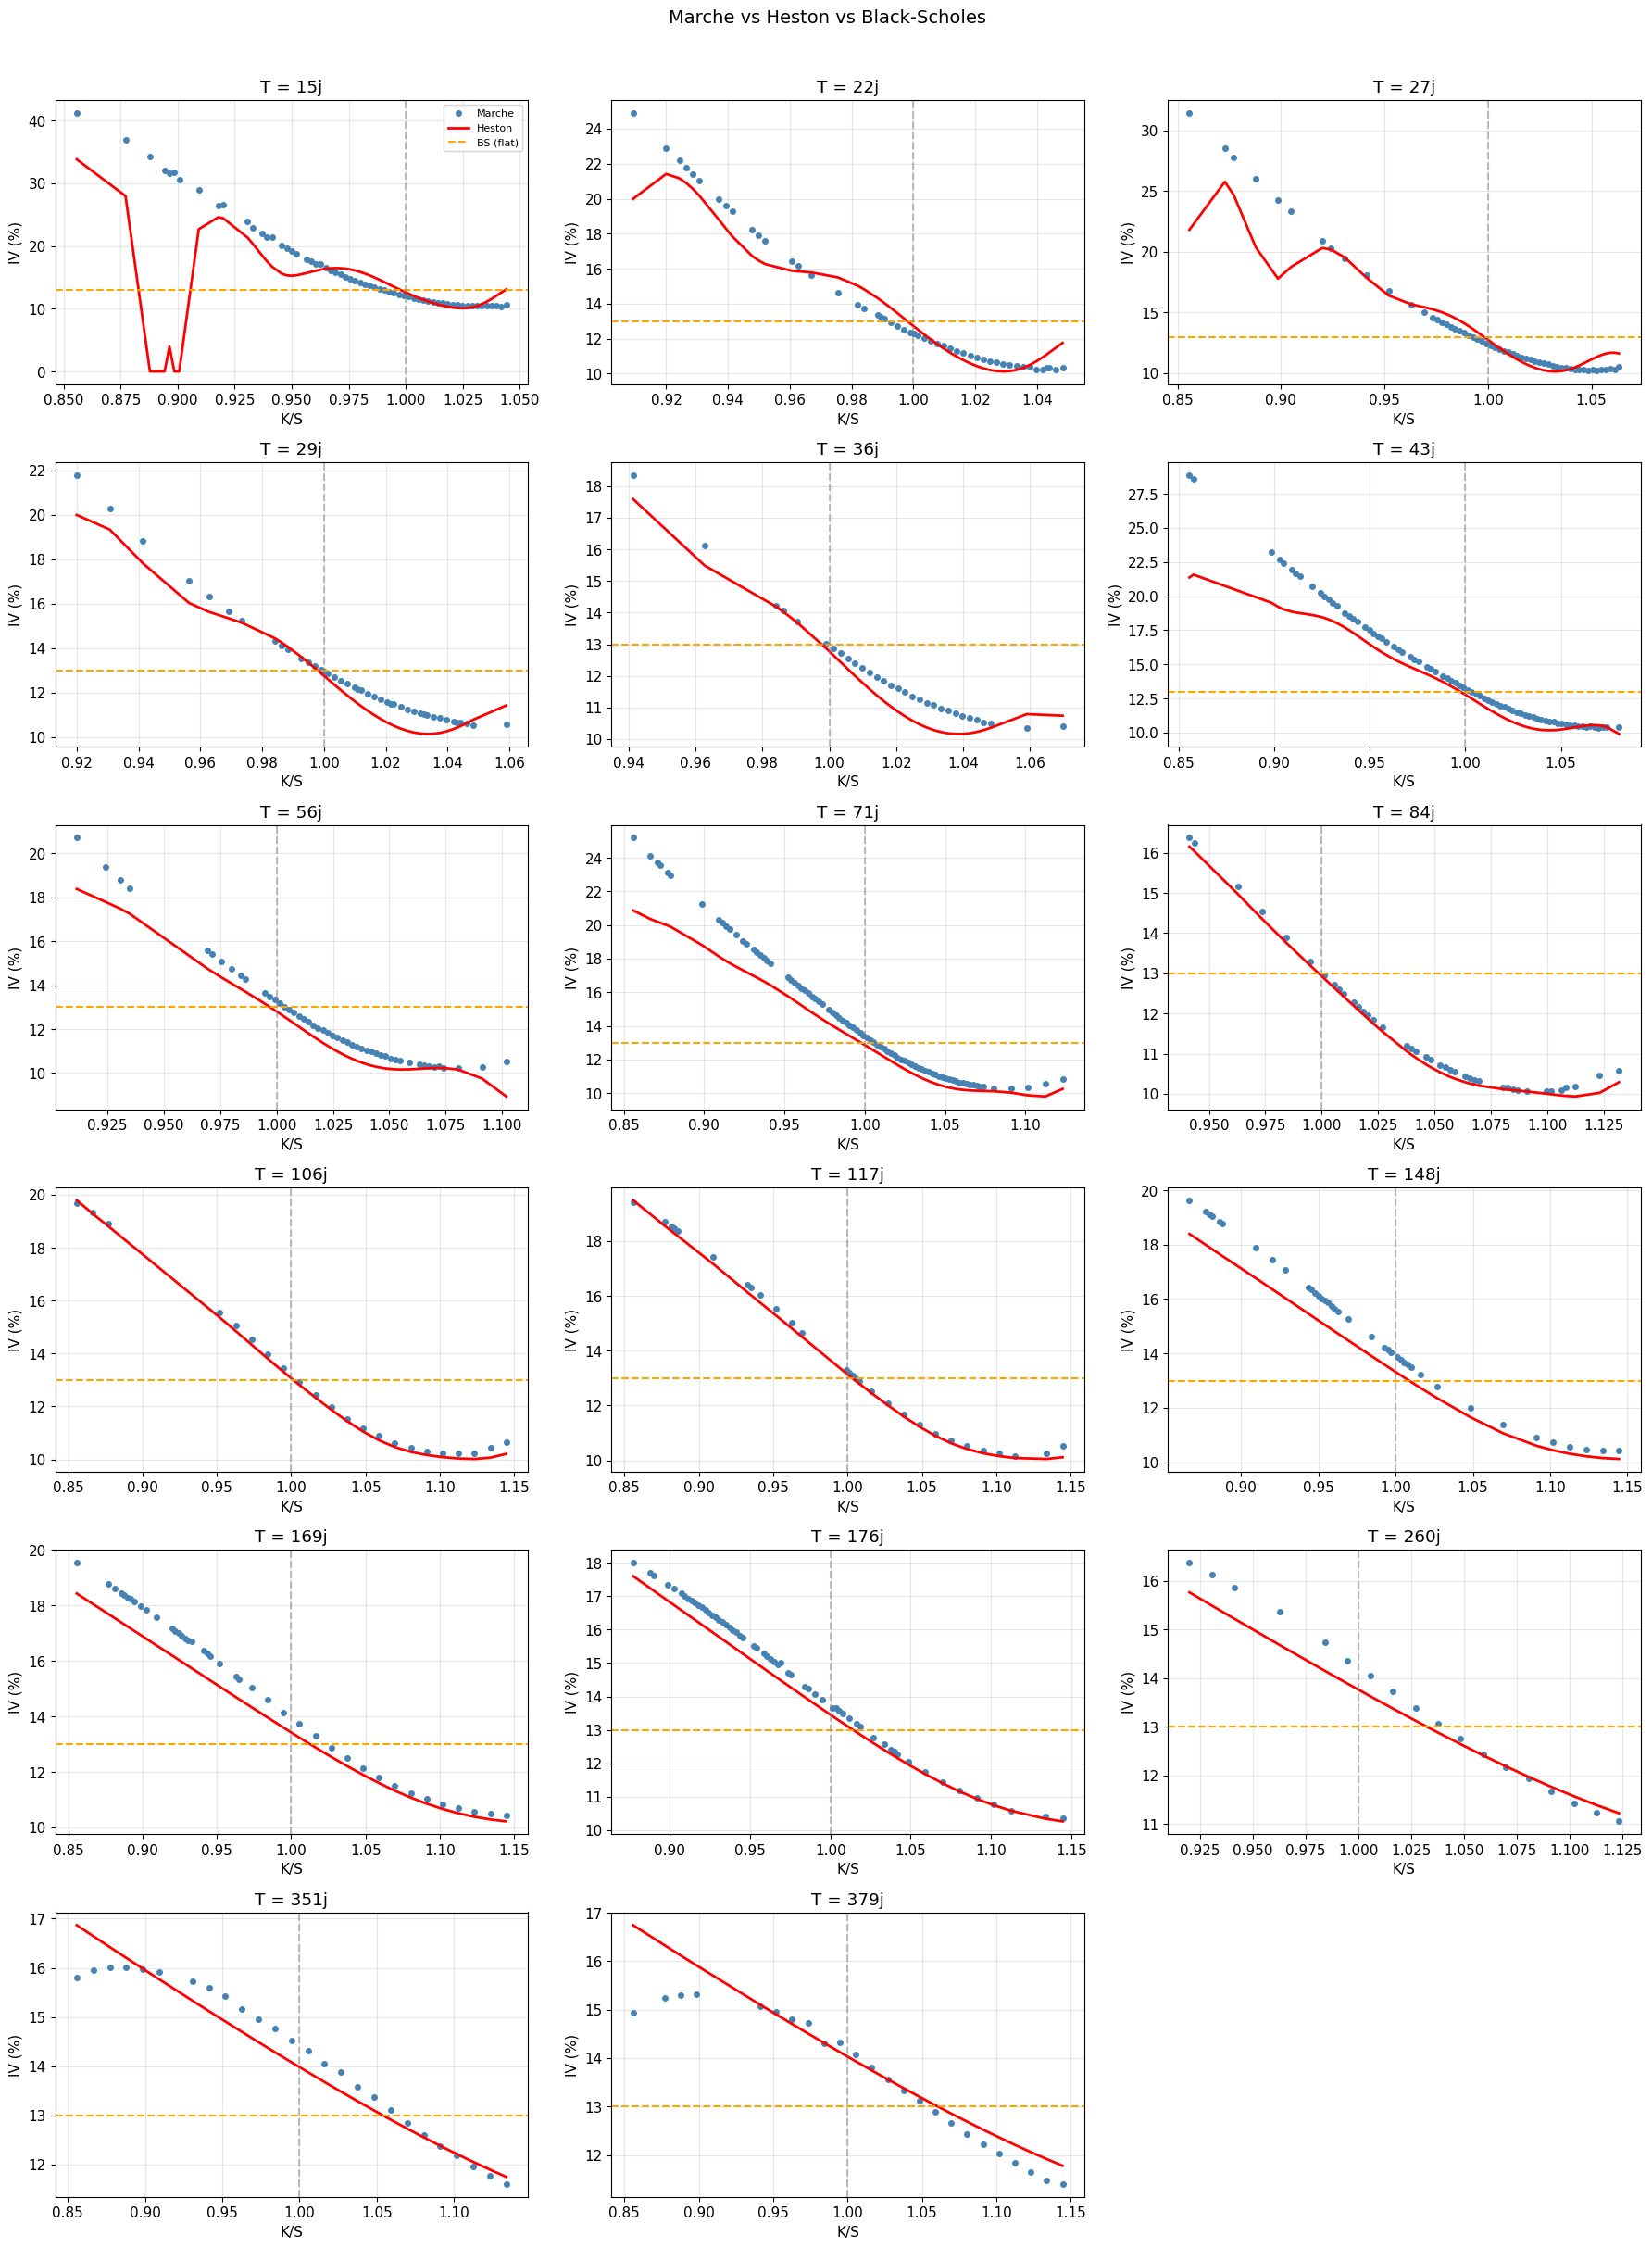

In [14]:
# BS vs Heston vs Marche — smiles superposes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)

for idx, Td in enumerate(mats):
    ax = axes[idx // n_cols, idx % n_cols]
    sub = df[df['maturity_days'] == Td].sort_values('moneyness')
    ax.plot(sub['moneyness'], sub['implied_volatility'] * 100, 'o', color='steelblue', ms=4, label='Marche')
    ax.plot(sub['moneyness'], sub['iv_heston'] * 100, '-', color='red', lw=2, label='Heston')
    ax.axhline(sigma_bs * 100, color='orange', ls='--', lw=1.5, label='BS (flat)')
    ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
    ax.set_title(f'T = {Td}j')
    ax.set_xlabel('K/S')
    ax.set_ylabel('IV (%)')
    if idx == 0:
        ax.legend(fontsize=8)

for idx in range(len(mats), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle('Marche vs Heston vs Black-Scholes', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

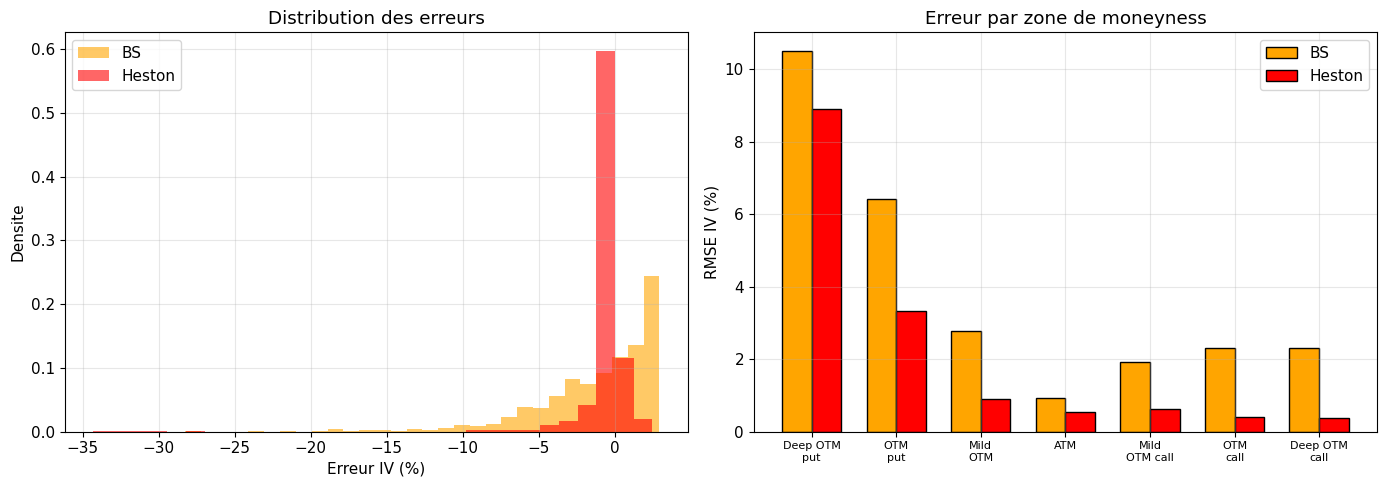

In [15]:
# Distribution des erreurs BS vs Heston
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(err_bs, bins=30, alpha=0.6, color='orange', label='BS', density=True)
ax1.hist(err_heston, bins=30, alpha=0.6, color='red', label='Heston', density=True)
ax1.set_xlabel('Erreur IV (%)')
ax1.set_ylabel('Densite')
ax1.set_title('Distribution des erreurs')
ax1.legend()

# Erreur par zone de moneyness
bins_m = [0.85, 0.90, 0.95, 0.98, 1.02, 1.05, 1.10, 1.15]
labels_m = ['Deep OTM\nput', 'OTM\nput', 'Mild\nOTM', 'ATM', 'Mild\nOTM call', 'OTM\ncall', 'Deep OTM\ncall']
df['moneyness_bin'] = pd.cut(df['moneyness'], bins=bins_m, labels=labels_m)

rmse_by_zone_bs = df.groupby('moneyness_bin', observed=False).apply(
    lambda g: np.sqrt(np.mean((sigma_bs - g['implied_volatility'])**2)) * 100
)
rmse_by_zone_h = df.groupby('moneyness_bin', observed=False).apply(
    lambda g: np.sqrt(np.mean((g['iv_heston'] - g['implied_volatility'])**2)) * 100
)

x = np.arange(len(labels_m))
w = 0.35
ax2.bar(x - w/2, rmse_by_zone_bs, w, color='orange', label='BS', edgecolor='black')
ax2.bar(x + w/2, rmse_by_zone_h, w, color='red', label='Heston', edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_m, fontsize=8)
ax2.set_ylabel('RMSE IV (%)')
ax2.set_title('Erreur par zone de moneyness')
ax2.legend()

plt.tight_layout()
plt.show()

## 8 — Resume

| | Black-Scholes | Heston |
|---|---|---|
| Volatilite | Constante | Stochastique (5 params) |
| Smile/Skew | Non | Oui |
| Structure par terme | Non | Oui |
| Calibration | Triviale (1 param) | Optimisation non-lineaire |
| Feller | N/A | A verifier |

In [ ]:
# Resume final
print(f"\n  Donnees : {len(markets)} jours, {sum(len(m.strikes) for m in markets)} options")
print(f"  Meilleure methode : {best.method}")
print(f"  RMSE IV Heston    : {rmse_h:.3f}%")
print(f"  RMSE IV BS        : {rmse_bs:.3f}%")
print(f"  Amelioration      : {rmse_bs/rmse_h:.1f}x")
print(f"\n  Condition de Feller : {'Satisfaite' if best.params.feller_satisfied else 'Violee'}")
p = best.params
print(f"    2*kappa*theta = {2*p.kappa*p.theta:.4f}")
print(f"    sigma^2       = {p.sigma**2:.4f}")
print(f"\n  Parametres calibres :")
print(f"    v0    = {p.v0:.6f}  (vol spot  = {np.sqrt(p.v0):.2%})")
print(f"    kappa = {p.kappa:.6f}")
print(f"    theta = {p.theta:.6f}  (vol LT    = {np.sqrt(p.theta):.2%})")
print(f"    sigma = {p.sigma:.6f}  (vol of vol)")
print(f"    rho   = {p.rho:.6f}  (correlation)")


  Donnees : 5 jours, 3602 options
  Meilleure methode : Hybride (DE + LM)
  RMSE IV Heston    : 2.848%
  RMSE IV BS        : 4.226%
  Amelioration      : 1.5x

  Condition de Feller : Violee
    2*kappa*theta = 0.4320
    sigma^2       = 1.0079

  Parametres calibres :
    v0    = 0.018029  (vol spot  = 13.43%)
    kappa = 10.449385
    theta = 0.020673  (vol LT    = 14.38%)
    sigma = 1.003947  (vol of vol)
    rho   = -0.663355  (correlation)


: 